Codes are from
https://glowingpython.blogspot.com/2011/12/lissajous-curves.html

For details
https://en.wikipedia.org/wiki/Lissajous_curve

In [1]:
import sys

sys.path.append('..')

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 


# sns.set(style="white", palette="muted", color_codes=True)
from matplotlib.offsetbox import AnchoredText
from matplotlib.ticker import FuncFormatter, StrMethodFormatter

%matplotlib inline

# import mpld3
# mpld3.enable_notebook()
np.set_printoptions(precision=2)

In [2]:
pct_formatter = StrMethodFormatter('{x:.1%}')

# There are five preset seaborn themes: darkgrid, whitegrid, dark, white, and ticks
sns.set_style("darkgrid")
# sns.set() 
# blue, green, *_ = sns.color_palette()

plt.rc('figure', figsize=(12, 10))

LABELSIZE = 14
plt.rc('axes', labelsize=LABELSIZE)
plt.rc('axes', titlesize=LABELSIZE)
plt.rc('figure', titlesize=LABELSIZE)
plt.rc('legend', fontsize=LABELSIZE)
plt.rc('xtick', labelsize=LABELSIZE)
plt.rc('ytick', labelsize=LABELSIZE)
plt.rc('axes', labelpad=18)

# use LaTeX fonts in the plot
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

In [3]:
# # LATEX EXAMPLE 
#  # Example data
# t = np.arange(0.0, 1.0 + 0.01, 0.01)
# s = np.cos(4 * np.pi * t) + 2
 
# plt.plot(t, s)

# plt.xlabel(r'\textbf{time} (s)')
# plt.ylabel(r'\textit{voltage} (mV)',fontsize=16)
# plt.title(r"\TeX\ is Number "
#           r"$\displaystyle\sum_{n=1}^\infty\frac{-e^{i\pi}}{2^n}$!",
#           fontsize=16, color='gray')
# # Make room for the ridiculously large title.
# plt.subplots_adjust(top=0.8)

# #plt.savefig('tex_demo')
# plt.show()

### Create Parametrized X, Y's using Lissajous curves
Put in the xy_list list

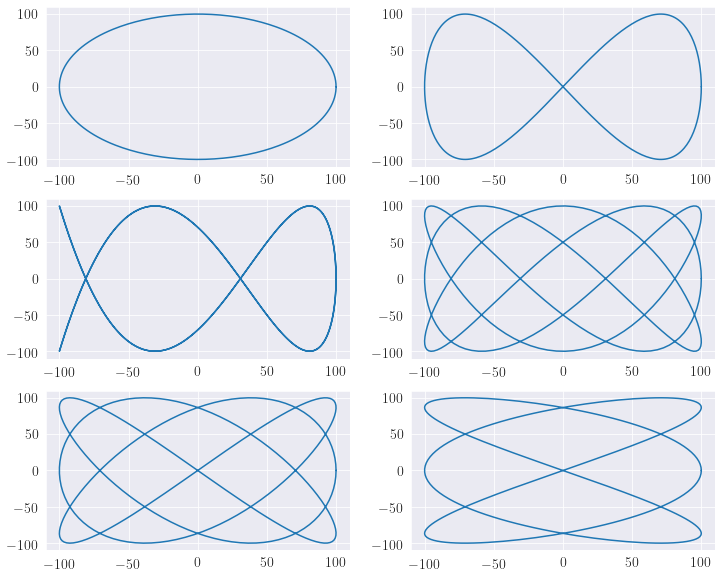

In [4]:
ai = [1,1, 2,3,3, 3, 2] # plotting the curves for
bi = [1,2, 5,5,4, 2, 3] # different values of a/b

delta = np.pi/2 
ti = np.linspace(0, 2*np.pi,300)

xy_list = []
mscale = 100

for i in range(0,6):
    xi = np.sin(ai[i] * ti + delta)
    yi = np.sin(bi[i] * ti)
    
    xy_list.append([xi*mscale, yi*mscale])
    
    plt.subplot(3,2,i+1)
    plt.plot(xi*mscale,yi*mscale)



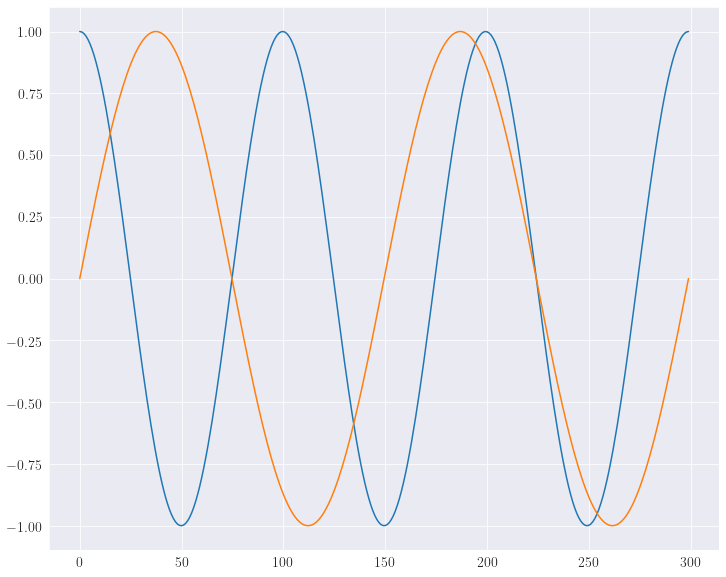

In [5]:
plt.plot(xi)
plt.plot(yi)

### Compute Path Heading Angles using Differential Geometry 


In [6]:
import sympy as sp
sp.init_printing()

In [7]:
x, y, δ, a, b, t, Ψ, κ = sp.symbols('x y δ a b t Ψ κ')

In [8]:
x = sp.sin(a*t + δ)
y = sp.sin(b*t)
x, y

In [9]:
Ψ = sp.atan2(sp.diff(y,t), sp.diff(x,t))
Ψ

In [10]:
xdot = sp.diff(x, t)
ydot = sp.diff(y, t)
rdot = [xdot, ydot]

rdot

In [11]:
xddot = sp.diff(xdot, t)
yddot = sp.diff(ydot, t)
rddot = [xddot, yddot]

rddot

In [12]:
bi[0]

### Choose the Curve

$$ \kappa=\frac{\left\|\vec{r}^{\prime}(t) \times \vec{r}^{\prime \prime}(t)\right\|}{\left\|\vec{r}^{\prime}(t)\right\|^{3}} $$

In [13]:
rs = sp.zeros(2, 1) # position vector
rs[0,0] =  sp.sin(a*t + δ)
rs[1,0] = sp.sin(b*t)


In [14]:
sp.diff(rs, t)

⎡a⋅cos(a⋅t + δ)⎤
⎢              ⎥
⎣  b⋅cos(b⋅t)  ⎦

In [15]:
sp.diff(rs, t, 2)

⎡  2             ⎤
⎢-a ⋅sin(a⋅t + δ)⎥
⎢                ⎥
⎢    2           ⎥
⎣  -b ⋅sin(b⋅t)  ⎦

In [16]:
n = 1 # curve to choose
xi, yi = xy_list[n]
κi_list = []
ψi_list = []

for i in range(ti.shape[0]):
    rdoti = [ai[n]*np.cos(ai[n]*ti[i] + delta)*mscale, bi[n]*np.cos(bi[n]*ti[i])*mscale]
    rddoti =[-mscale*np.sin(ai[n]*ti[i] + delta)*ai[n]**2, -mscale*np.sin(bi[n]*ti[i])*bi[n]**2]
    
    #curvature
    κi = np.cross(rdoti, rddoti) / np.linalg.norm(rdoti)**3
    
    #heading angle
    ψi = np.arctan2(bi[n]*np.cos(bi[n]*ti[i]), ai[n]*np.cos(ai[n]*ti[i]+delta))
    
    
    ψi_list.append(ψi)
    κi_list.append(κi)
    

In [17]:
Ψi = np.array(ψi_list)
κi = np.array(κi_list)

In [18]:
Ψi.shape, κi.shape

Text(0.5, 1.0, 'Heading Angle')

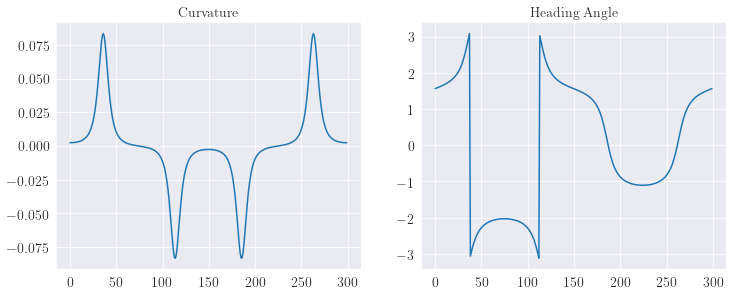

In [19]:
plt.subplot(2, 2, 1)
plt.plot(κi)
plt.title('Curvature')

plt.subplot(2, 2, 2)
plt.plot(Ψi)
plt.title('Heading Angle')

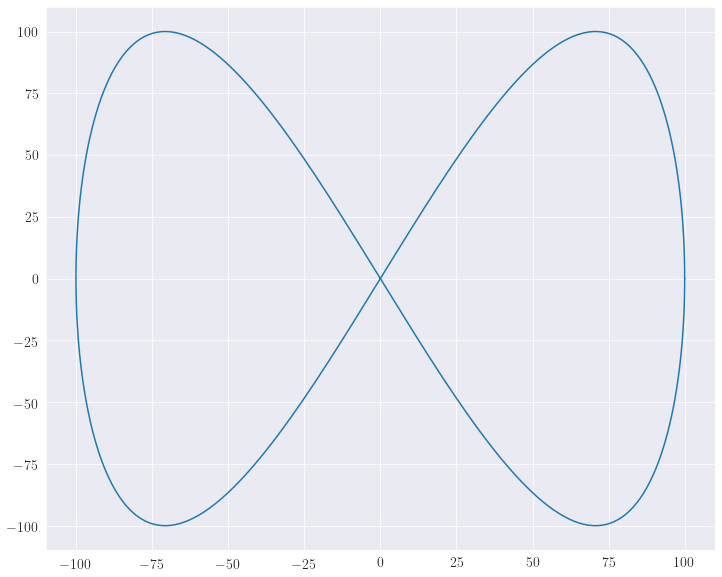

In [20]:
plt.plot(xi, yi)

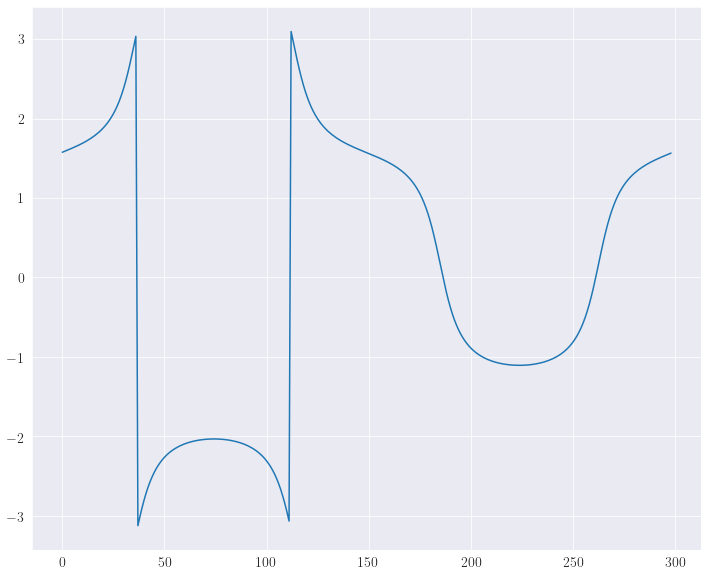

In [21]:
plt.plot(np.arctan2(np.diff(yi), np.diff(xi)))

### Distance travelled
The index of the path lookup table will be the distance travelled. Cumulative Sum

In [22]:
si = np.cumsum(np.hypot(np.diff(xi), np.diff(yi)))
si = np.append(0, si) # at the start point, s= 0

Δsi = np.diff(si)
Δxi_si = np.diff(xi) / Δsi
Δyi_si = np.diff(yi) / Δsi
 

In [23]:
# plt.plot(Δxi_si, Δyi_si)
# plt.plot(xi, yi)

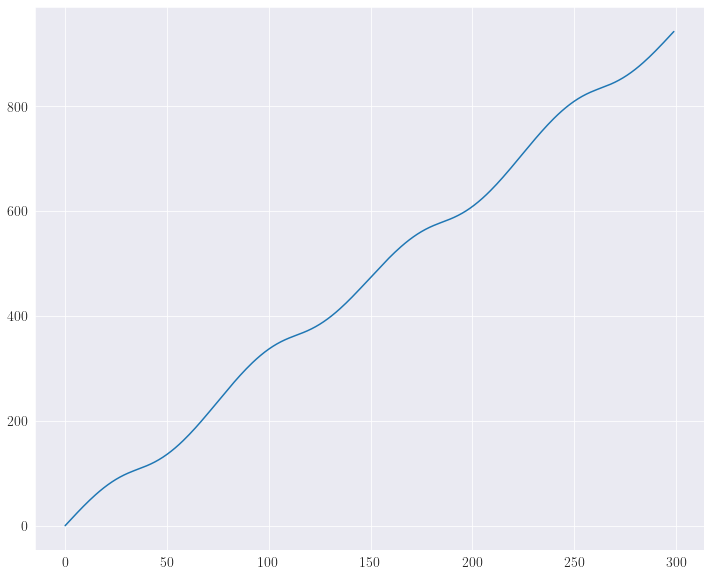

In [24]:
plt.plot(si)

### Before saving the differences $\Delta s \; \Delta x \; and \; \Delta y \;$

The length of differences and the original values should have the same length to put all of them into the same matrix. We augment the differences with 0 at the end.



In [25]:
Δsi = np.append(Δsi, 0)
Δxi_si = np.append(Δxi_si, 0)
Δyi_si = np.append(Δyi_si, 0)

Text(0, 0.5, 'Curve Length Intervals')

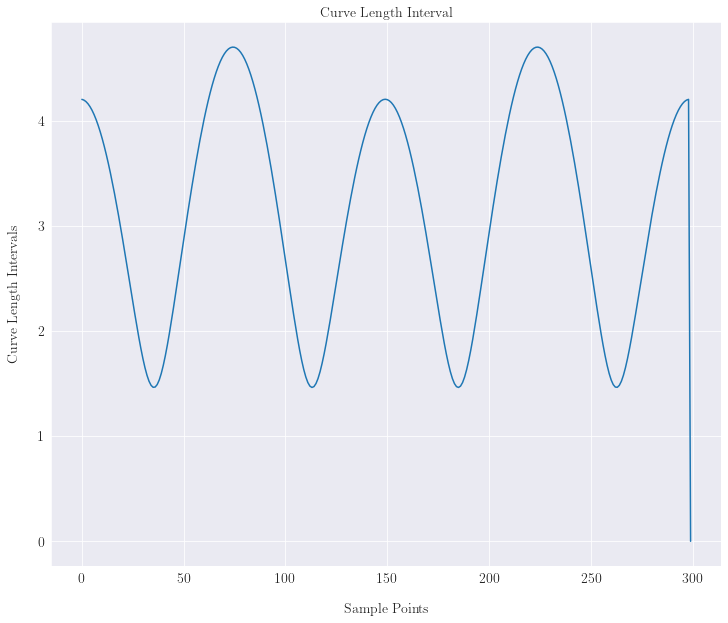

In [26]:
plt.plot(Δsi)
plt.title('Curve Length Interval')
plt.xlabel('Sample Points')
plt.ylabel('Curve Length Intervals')

**`As seen in the figure above, the intervals are not equidistant`**. To facilitate the things in our algorithms, we need to define equidistant intervals, so that we can paremetrize our data matrix with the distance of curve length 's' and its equidistant intervals.  

In [27]:
smax = si.max()
smax

In [28]:
sie = np.arange(start=0, stop=smax, step=0.5)
sie.max()

In [29]:
xie = np.interp(sie, si, xi)
yie = np.interp(sie, si, yi)
Ψie = np.interp(sie, si, Ψi)
κie = np.interp(sie, si, κi)

In [30]:
Δsie = np.diff(sie)
Δxie_sie = np.diff(xie) / Δsie
Δyie_sie = np.diff(yie) / Δsie

In [31]:
Δsie = np.append(Δsie, Δsie[-1])
Δxie_sie = np.append(Δxie_sie, Δxie_sie[-1])
Δyie_sie = np.append(Δyie_sie, Δxie_sie[-1]) 

### Save to a txt or csv file

In [32]:
sie.shape, xie.shape, yie.shape, Ψie.shape, κie.shape, Δsie.shape, Δxie_sie.shape, Δyie_sie.shape

In [33]:
path = np.vstack((sie, xie, yie, Ψie, κie, Δsie, Δxie_sie, Δyie_sie)).T

In [34]:
path.shape

In [35]:
filepath = '../test_path.txt'

In [36]:
np.savetxt(filepath, path,  delimiter=' ')   # x,y,z equal sized 1D arrays

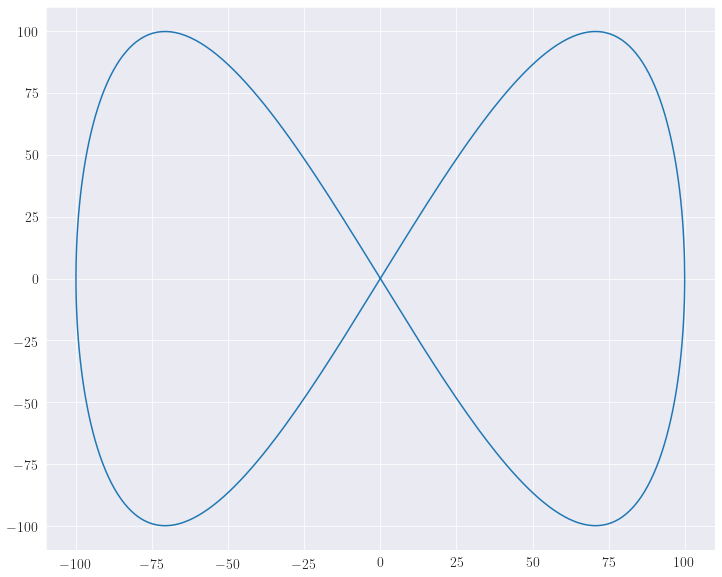

In [37]:
plt.plot(xie,yie)

In [38]:
yie

array([ 0.  ,  0.5 ,  1.  , ..., -1.39, -0.89, -0.39])

In [39]:
xie

array([100.  , 100.  ,  99.99, ...,  99.99, 100.  , 100.  ])

In [40]:
Ψie

array([1.57, 1.57, 1.57, ..., 1.57, 1.57, 1.57])

In [41]:
np.rad2deg(Ψie[0])